In [1]:
%cd /home/smalani/PartialObservations
from BandFModel import datagen

import numpy as np

data_train = np.load("data/training_data.npy", allow_pickle=True)
data_train_par = np.load("data/training_data_par.npy", allow_pickle=True)
data_train_detail_t = np.load("data/training_data_detail_t.npy", allow_pickle=True)
data_train_detail_x = np.load("data/training_data_detail_x.npy", allow_pickle=True)
data_train_detail_par = np.load("data/training_data_detail_par.npy", allow_pickle=True)

/home/smalani/PartialObservations


In [2]:
# print(data.shape)

In [3]:
from main import preprocess
import config

dataset_train = preprocess.Dataset(data_train,data_train_par)

(200, 163, 6)
(163,)
(25,)
(25,)


Text(0, 0.5, 'Z')

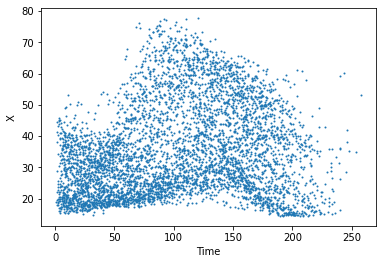

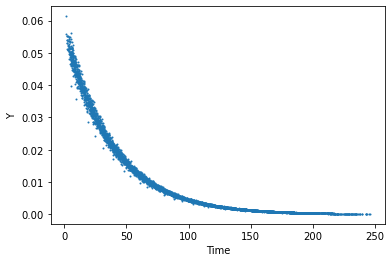

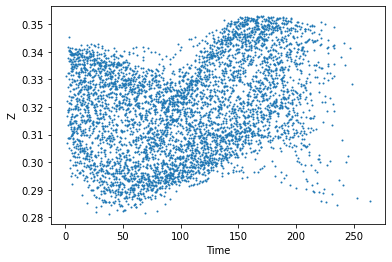

In [4]:
print(dataset_train.x.shape)
print(np.array(dataset_train.full_times_arr)[0,:].shape)

print(dataset_train.x[0,:,0][dataset_train.x[0,:,0] == dataset_train.x[0,:,0]].shape)
print(np.array(dataset_train.full_times_arr)[0,:][dataset_train.x[0,:,0] == dataset_train.x[0,:,0]].shape)

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(np.array(dataset_train.full_times_arr)[:,:],
            dataset_train.x[:,:,0],
            s=1)
plt.xlabel('Time')
plt.ylabel('X')

plt.figure()
plt.scatter(np.array(dataset_train.full_times_arr)[:,:],
            dataset_train.x[:,:,1], s=1)
plt.xlabel('Time')
plt.ylabel('Y')


plt.figure()
plt.scatter(np.array(dataset_train.full_times_arr)[:,:],
            dataset_train.x[:,:,2], s=1)
plt.xlabel('Time')
plt.ylabel('Z')

In [5]:
%cd /home/smalani/PartialObservations

from config import config
from main.utils import Network, MLP
import torch

f = np.load("minmax/minmax.npz")

xmax = f['arr_0']
xmin = f['arr_1']
print(xmax)
print(xmin)

norm_func = lambda input, device: (input - torch.tensor(xmin).float().to(device)) / \
                        ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10)
inv_norm_func = lambda input, device: input * ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10) \
                                + torch.tensor(xmin).float().to(device)

# Create the network architecture

if config["MODEL"]["BOX"] == 'Black':
    # Create the network architecture
    mlp = MLP(5, config["MODEL"]["NUM_HIDDEN"], 6)
    
    class my_Network(Network):
        def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                        inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                        tf_prop=1., integrator='RK4', add_par_num=0):
            super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                        inv_norm_func, init_available, device, 
                        tf_prop, integrator, add_par_num)

            self.additional_pars = torch.nn.Parameter((torch.zeros(6)-1).to(self.device), requires_grad = True) 

        def output(self, x, par):

            # ANN_input = torch.cat((self.norm_func(x), par/20), dim=-1)
            ANN_input = self.norm_func(x)[...,[0,2,3,4,5]]
            out = self.net(ANN_input) #* (2 ** (self.additional_pars))
            # print(out)
            out = self.inv_norm_func(out) * (2 ** (7 * self.additional_pars))
            zeros = torch.zeros((out[...,[0]].shape)).to(self.device)
            out = torch.cat((out[...,[0]],zeros,out[...,2:]), -1)
            # print(out)
            # assert False
            # out = out * torch.tensor([1000, 5e-168, 2.7, 1000, 17000, 6.2]).to(self.device)
            return out

elif config["MODEL"]["BOX"] == 'Grey' or config["MODEL"]["BOX"] == 'Gray':
    
    # Create the network architecture
    mlp = MLP(6, config["MODEL"]["NUM_HIDDEN"], 3)
    
    if config["MODEL"]["Parameters"] == 'Trainable':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                self.additional_pars = torch.nn.Parameter((torch.cat(((torch.tensor([0.4476, -0.4859, -0.6419])), 
                                                                        (torch.zeros(4) + 1)))).to(self.device), 
                                                            requires_grad = True)

            def output(self, x_input, par):
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                ANN_output = ANN_output * (100 ** (self.additional_pars[:3]))

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)

                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)                

                omega = self.additional_pars[-4] * 10
                sigma = self.additional_pars[-3] * 10
                rho = self.additional_pars[-2] / 10
                eta = self.additional_pars[-1]

                alpha, uf, _, _, _, _, _, _, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun()

                output = []

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)
                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars[:3]))

                return ANN_output
    elif config["MODEL"]["Parameters"] == 'Fixed':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                # self.additional_pars = torch.nn.Parameter((torch.zeros(2)-0.5).to(self.device), 
                #                             requires_grad = True)
                self.additional_pars = torch.nn.Parameter((torch.tensor([0.4476, -0.4859, -0.6419])).to(self.device), 
                                                                requires_grad = True)

                

            def output(self, x_input, par):
                
                # print('outputs')
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                # print(ANN_output)
                ANN_output = ANN_output * (100 ** (self.additional_pars))
                # print(ANN_output)
                # assert False

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)

                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)

                alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun(D=1/7.3, sf=2.5)

                # u2_prime_y = y * phi1 * v / (1+v)

                output = []

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)

                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                # output.append(torch.zeros(output[-1].shape).to(self.device))

                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars))

                return ANN_output

    else:
        raise ValueError("Tell me whether to train the parameters!")
else:
    raise ValueError("Tell me what box to use!")


network = my_Network(mlp, config["DATA"]["N_TRAIN"], 6, norm_func=norm_func, inv_norm_func=inv_norm_func, 
                      init_available=config["DATA"]["INIT_AVAILABLE"], integrator='RK4')
device = 'cpu'

filename = 'data/' + 'model_' + '.net'

print(filename)

#         omit_dict = {"initial_x1": "initial_x1", "initial_x2": "initial_x2"}
#         model_dict = network.state_dict()
#         model_dict.pop("initial_x1")
#         model_dict.pop("initial_x2")

#         chosen_dict = {k: v for k, v in omit_dict.items() if k in model_dict}
#         chosen_dict = {k: v for k, v in model_dict.items() if k not in omit_dict}

#         model_dict.update(chosen_dict)
state_dict = torch.load(filename, map_location=torch.device(device))
#     state_dict.pop('initial_x')
#         network.load_state_dict(torch.load(filename, map_location=torch.device(device)))
network.load_state_dict(state_dict, strict=True)
#     network.initial_x1 = torch.tensor(dataset_test.x1[0][0]/2).unsqueeze(0).unsqueeze(0)
#     network.initial_x2 = torch.tensor(dataset_test.x2[0][0]/10).unsqueeze(0).unsqueeze(0)

print(network)
#     network.to(device)

network.double()

/home/smalani/PartialObservations
[7.76480999e+01 6.13450077e-02 3.52889567e-01 2.08507400e+02
 2.11354658e+03 8.21362308e-01]
[1.45181035e+01 1.12344629e-04 2.81247634e-01 3.24970859e+01
 3.97881635e+02 6.58996734e-01]
data/model_.net
my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=3, bias=True)
  )
)


my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [6]:
f = np.load("/home/smalani/PartialObservations/minmax/minmax.npz")

xmax = f['arr_0']
xmin = f['arr_1']

print('maxmins')
print(xmax)
print(xmin)


norm_func = lambda input, device: (input - torch.tensor(xmin).float().to(device)) / \
                        ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10)
inv_norm_func = lambda input, device: input * ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10) \
                                + torch.tensor(xmin).float().to(device)

maxmins
[7.76480999e+01 6.13450077e-02 3.52889567e-01 2.08507400e+02
 2.11354658e+03 8.21362308e-01]
[1.45181035e+01 1.12344629e-04 2.81247634e-01 3.24970859e+01
 3.97881635e+02 6.58996734e-01]


(200, 1000, 6)
torch.Size([200, 6])


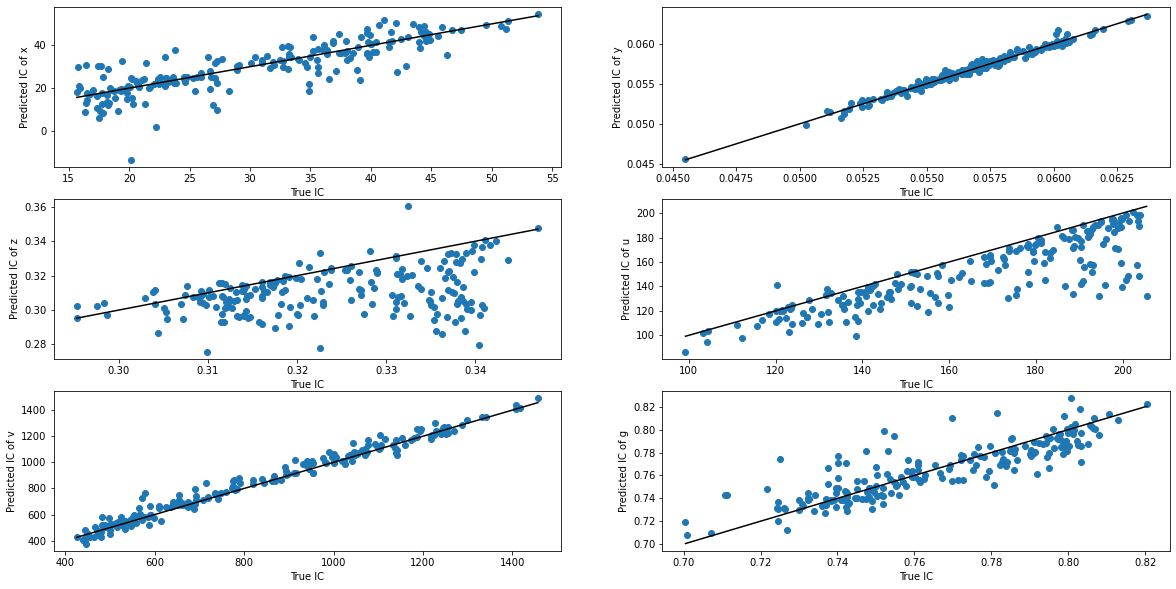

In [7]:
print(data_train_detail_x.shape)

print(network.initial_x.shape)

# for i in range(6):
#     plt.figure(figsize=(10,8))
#     plt.scatter(data_train_detail_x[:,0,i], inv_norm_func(network.initial_x, device='cuda')[:,i].cpu().detach().numpy())
#     plt.plot([min(data_train_detail_x[:,0,i]), max(data_train_detail_x[:,0,i])], [min(data_train_detail_x[:,0,i]), max(data_train_detail_x[:,0,i])], 'k-')

plt.figure(figsize=(20,10))

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    plt.subplot(int(str(32) + str(i+1)))
    plt.scatter(data_train_detail_x[:,0,i], inv_norm_func(network.initial_x, device='cuda')[:,i].cpu().detach().numpy())
    plt.plot([min(data_train_detail_x[:,0,i]), max(data_train_detail_x[:,0,i])], [min(data_train_detail_x[:,0,i]), max(data_train_detail_x[:,0,i])], 'k-')
    plt.ylabel('Predicted IC of ' + labels[i])
    plt.xlabel('True IC')
plt.show()

In [8]:
dataset_train = preprocess.Dataset(data_train, data_train_par)

# t_in = torch.tensor(data_train_traj[2]).unsqueeze(-1).to(network.device)
# x_in = torch.tensor(data_train_traj[3]).to(network.device)
# p_in = torch.tensor(data_train_traj[4]).unsqueeze(-1).to(network.device)

t_in = torch.tensor(np.array(dataset_train.full_times_arr[:])).unsqueeze(-1).to(network.device)
x_in = torch.tensor(dataset_train.x[:,:,:]).to(network.device)
p_in = torch.tensor(dataset_train.p[:,:,:]).to(network.device)

network.tf_prop = 0

ANN_output = network.forward(x_in, p_in, t_in, index=np.arange(x_in.shape[0])).cpu().detach().numpy()
print(ANN_output.shape)


# print(x_in.shape)
# print(t_in.shape)
# print(ANN_output.shape)
print(t_in[0,:10])
print(x_in[0,:10,:])
# print(t_in[0,:20,0])
# print(ANN_output[0,:20,0])
print('-------------')
# print(x_in[2,-5:,0])
# print(t_in[2,-5:,0])
# print(x_in[2,[0],:])
# print(t_in[2,[0],:])

(200, 163, 6)
tensor([[ 0.0000],
        [ 2.5916],
        [ 3.7900],
        [ 4.4486],
        [ 5.3371],
        [ 6.4766],
        [10.1914],
        [10.5717],
        [10.7102],
        [12.5877]], device='cuda:0', dtype=torch.float64)
tensor([[       nan,        nan,        nan,        nan,        nan,        nan],
        [       nan,        nan,        nan, 1.9809e+02,        nan,        nan],
        [       nan,        nan, 3.1400e-01,        nan,        nan,        nan],
        [       nan, 5.0057e-02,        nan,        nan,        nan,        nan],
        [       nan,        nan,        nan,        nan, 4.9543e+02,        nan],
        [1.8215e+01,        nan,        nan,        nan,        nan,        nan],
        [       nan,        nan,        nan, 1.9805e+02,        nan,        nan],
        [       nan, 4.2802e-02,        nan,        nan,        nan,        nan],
        [       nan,        nan,        nan,        nan,        nan, 7.3090e-01],
        [       nan

In [9]:
print(data_train_detail_x.shape)
print(data_train_detail_t.shape)

(200, 1000, 6)
(200, 1000)


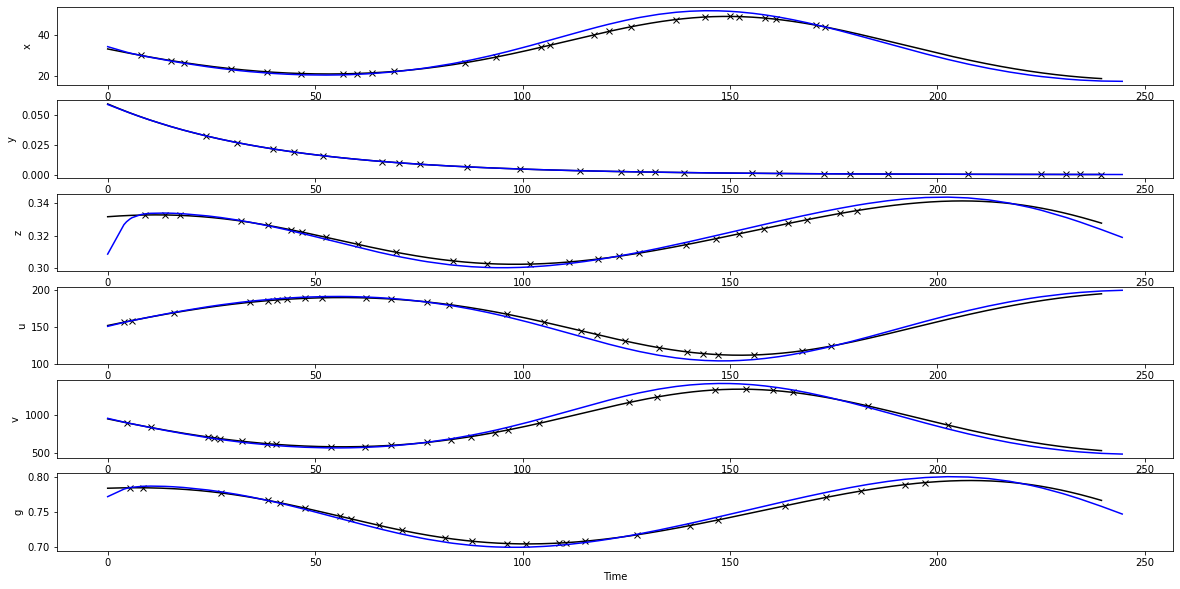

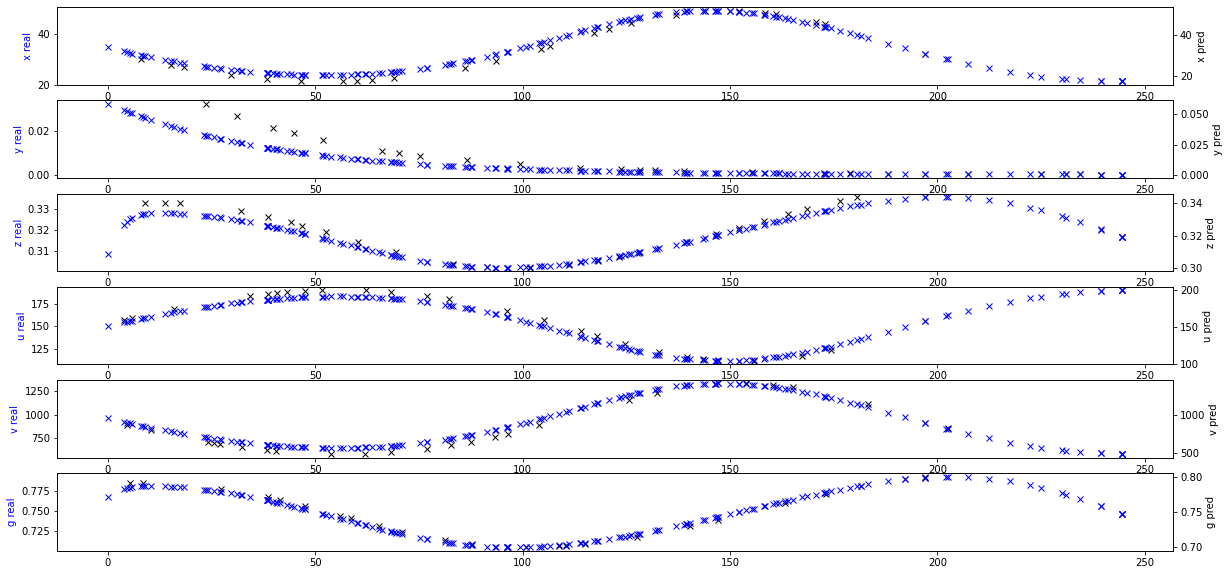

In [10]:
traj = 1
length = 10000

plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(t_in[traj,:length].detach().cpu().numpy(), 
            x_in[traj,:length,i].detach().cpu().numpy(), 'kx')
    ax.plot(data_train_detail_t[traj,:], data_train_detail_x[traj,:,i],'k')
    ax.plot(t_in[traj,:length].detach().cpu().numpy(), 
            ANN_output[traj,:length,i], 'b')
#     ax.plot(t_in[traj+2,:length].detach().cpu().numpy(), 
#             ANN_output[traj+2,:length,i], 'k--')    
    ax.set_ylabel(labels[i])
#     plt.ylabel(labels[i])
plt.xlabel('Time')
plt.show()

plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(t_in[traj,:length].detach().cpu().numpy(), 
            x_in[traj,:length,i].detach().cpu().numpy(), 'kx')
    ax2 = ax.twinx()
    ax2.plot(t_in[traj,:length].detach().cpu().numpy(), 
            ANN_output[traj,:length,i], 'bx')    
    ax.set_ylabel(labels[i] + ' real', color='b')
    ax2.set_ylabel(labels[i] + ' pred', color='k')
#     plt.ylabel(labels[i])
plt.xlabel('Time')
plt.show()

In [11]:
%cd /home/smalani/PartialObservations
from BandFModel.datagen import par_fun, ode_fun
from scipy.integrate import solve_ivp

import numpy as np

index = 5
    
tspan = [dataset_train.full_times_arr[index][0],dataset_train.full_times_arr[index][-1]*10]


def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

sol_pred = solve_ivp(ode_NN_func, y0=data_train_detail_x[index,0,:], 
                t_span=tspan, 
                args=(dataset_train.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

initial = inv_norm_func(network.initial_x[index,:], device=network.device).detach().cpu().numpy()

sol_pred_init = solve_ivp(ode_NN_func, y0=initial, 
                t_span=tspan, 
                args=(dataset_train.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

print(dataset_train.x.shape)
a,b,c,d,e,f = dataset_train.x[index,0,:]

print(a)

print(data_train_detail_x.shape)

print(network.initial_x.shape)

sol_true = solve_ivp(ode_fun, y0=data_train_detail_x[index,0,:], 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)

sol_true_initial = solve_ivp(ode_fun, y0=initial, 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)

/home/smalani/PartialObservations
(200, 163, 6)
nan
(200, 1000, 6)
torch.Size([200, 6])


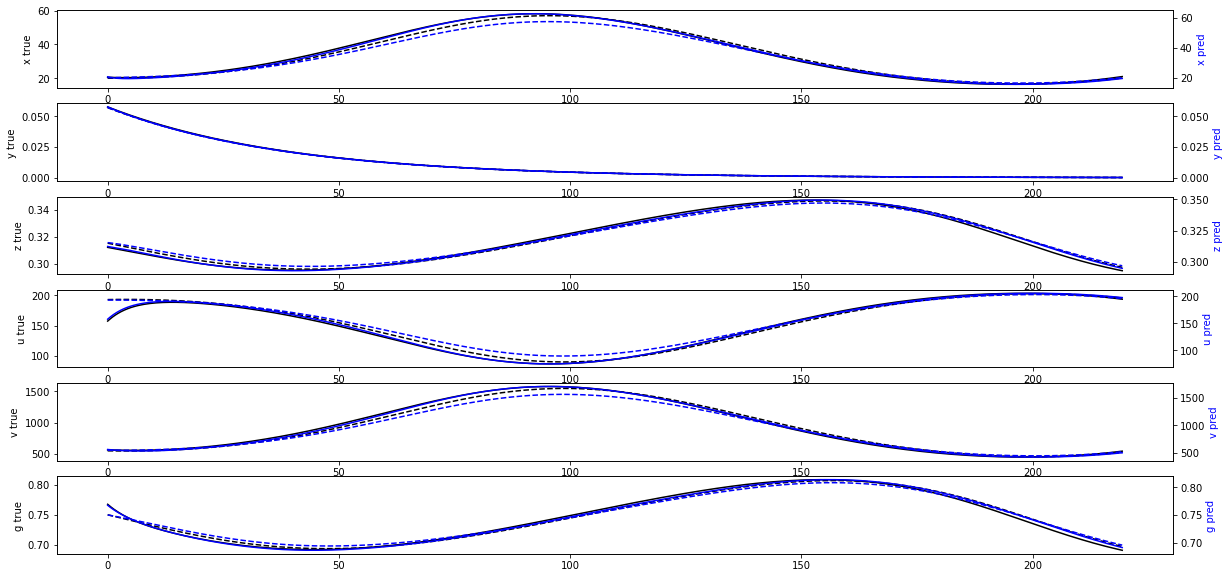

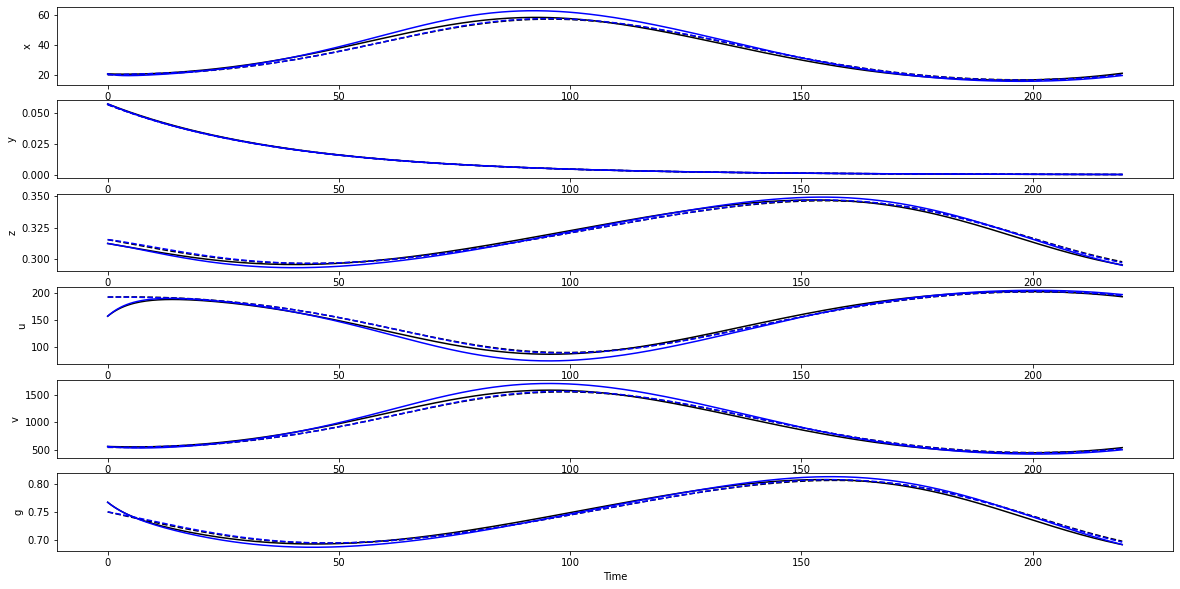

In [12]:
plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--')
    ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k')
    ax.set_ylabel(labels[i] + ' true', color='k')
    ax2 = ax.twinx()
    ax2.plot(sol_pred.t, sol_pred.y[i,:], 'b--')
    ax2.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b')
    ax2.set_ylabel(labels[i] + ' pred', color='b')
plt.xlabel('Time')
plt.show()

plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--')
    ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k')
    ax.set_ylabel(labels[i], color='k')
    # ax2 = ax.twinx()
    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b--')
    ax.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b')
    # ax.set_ylabel(labels[i] + ' pred', color='k')
plt.xlabel('Time')
plt.show()